# 1η Ατομική Εργασία
# Τεχνολογία και Ανάλυση Εικόνων και Βίντεο

# Θεωρητικό Μέρος

α) Η τιμή της παραμέτρου α καθορίζει το gaussian φίλτρο που εφαρμόζεται για την κατασκευή της γκαουσιανής πυραμίδας, καθώς περιγράφει τον τρόπο που λαμβάνεται υπόψη το κεντρικό στοιχείο στο οποίο τοποθετείται το φίλτρο σε σχέση με τα γειτονικά του. Παρατηρώντας το Fig 3 του άρθρου, συμπεράινουμε ότι μικρές τιμές της παραμέτρου α προσεγγίζουν ένα ομαλό γκαουσιανό βαθυπερατό φίλτρο, το οποίο "θολώνει" την εικόνα ομοιόμορφα ως προς τα γειτονικά στοιχεία του κάθε pixel της, ενώ καθώς αυξάνεται η παράμετρος α το φίλτρο "τριγωνοποιείται", με αποτέλεσμα να παίζει σημαντικότερο ρόλο το κεντρικό στοιχείο του φίλτρου και τα γειτονικά να έχουν από μηδενική εώς και αρνητική συνεισφορά στο προκύπτον αποτέλεσμα. Το τελευταίο φαινόμενο παρατηρείται για α = 0.6 και δίνει έμφαση στις έντονες διαφορές συχνότητας μεταξύ των γειτονικών pixel της εικόνας.

β) Ως εντροπία ορίζεται ο ελάχιστος αριθμός των bits που απαιτούνται για να αναπαραστήσουμε πλήρως κάθε διαφορετική τιμή των pixel μιας εικόνας. Μαθηματικά η εντροπία ορίζεται ως η μέση τιμή του αρνητικού λογαρίθμου μιας τυχαίας μεταβλητής, δηλαδή: $$ H(X) = - \sum P(x_i) \cdot \log_2(P(x_i)) $$
Όσο μεγαλύτερη εντροπία έχει μια εικόνα, τόσο μεγαλύτερος αριθμός διαφορετικών τιμών pixel έχουν μεγάλη πιθανότητα εμφάνισης, το οποίο διαισθητικά σημαίνει ότι η εικόνα έχει πολλές περιοχές με διαφορετικές αποχρώσεις. Όσο μικραίνει η εντροπία, μεγάλη πιθανότητα εμφάνισης έχει ένα μικρό πλήθος τιμών pixel, δηλαδή διαισθητικά η εικόνα είναι περισσότερο μονόχρωμη. Η μέγιστη τιμή της εντροπίας που μπορεί να έχει μια grayscale εικόνα, δεδομένου ότι κάθε pixel μπορεί να πάρει 256 διαφορετικές τιμές, είναι 8, καθώς $$2^8 = 256$$

γ) Το μέγεθος του bin, n, κατά την κβαντοποίηση ορίζεται ως το πλήθος των pixel που μπορούν να αναπαρασταθούν από την εκάστοτε τιμή του bin. Μεγαλύτερος αριθμός από bins σημαίνει μικρότερο μέγεθος τους και το αντίστροφο. Όσο μεγαλύτερο είναι το μέγεθος του bin, τόσο λιγότερα bins χρησιμοποιούνται και επομένως λιγότερες τιμές pixel αντιπροσωπεύονται, με αποτέλεσμα να προκύπτουν μεγαλύτερα σφάλματα κατά την ανακατασκευή. Αντιθέτως, μικρότερο μέγεθος bins σημαίνει περισσότερα bins, οπότε μεγαλύτερος αριθμός διαφορετικών τιμών pixel αντιπροσωπεύονται και επομένως το σφάλμα ανακατασκευής μειώνεται.

δ) Η κβάντιση επηρεάζεται από το πλήθος των επιπέδων της πυραμίδας ως εξής: στα υψηλότερα επίπεδα της πυραμίδας η εικόνα περιέχει λιγότερες λεπτομέρειες και μεγαλύτερη εντροπία, καθώς οι τιμές των γειτονικών pixel δε διαφέρουν σημαντικά, επομένως απαιτείται μεγαλύτερος αριθμός bins για κωδικοποίηση. Αντίθετα, στα χαμηλότερα επίπεδα, όπου αποθηκεύονται οι λεπτομέρειες της εικόνας, η εντροπία είναι μικρότερη. Παρόλο που στα χαμηλότερα επίπεδα έχουμε περισσότερα pixel, η πληροφορία που περιέχουν μπορεί να συμπιεστεί πιο αποτελεσματικά μέσω κβάντισης, καθώς μπορεί να χρησιμοποιηθεί μικρός αριθμός bins για την πλήρη αποτύπωση των λεπτομερειών.

# Εργαστηριακό Μέρος


##Α. Υλοποίηση Αλγορίθμου

In [2]:
import numpy as np
from scipy import signal
from skimage import data
from PIL import Image
from matplotlib import pyplot as plt
import math

In [3]:
def GKernel(a):
    b = 1/4
    c = 1/4-a/2
    w = np.array([c,b,a,b,c])
    w2d = np.outer(w,w) # παραγωγή δισδιάστατου φίλτρου από το μονοδιάστατο μέσω εξωτερικού γινομένου των στοιχείων του
    return w2d

In [4]:
def GREDUCE(I,h):
    conv = signal.convolve2d(I, h, mode='same') # συνέλιξη με μέγεθος εξόδου ίσο με την είσοδο
    reduced = conv[::2,::2]
    return reduced

In [5]:
def GPyramid(I, a, depth):
    h = GKernel(a)
    pyramid = [I]
    for i in range(depth-1):
        pyramid.append(GREDUCE(pyramid[i],h))
    return pyramid

In [6]:
def GEXPAND(I, h):
    sizex = 2*len(I)-1
    sizey = 2*len(I[0])-1
    padded = np.pad(I,2)
    result = np.zeros((sizex,sizey))
    for i in range(sizex):
        for j in range(sizey):
            for m in range(-2,3):
                for n in range(-2,3):
                    xidx = (i+2)-m
                    yidx = (j+2)-n
                    if xidx % 2 == 0 and yidx % 2 == 0:
                        result[i][j] += 4 * h[m+2][n+2] * padded[xidx//2][yidx//2]
    return result

In [7]:
def change_dimensions(I, N):    # συνάρτηση για να αλλάξουμε τις διαστάσεις της εικόνας σε (Mc * 2^N + 1, Mr * 2^N + 1), καθώς και για συμβατότητα σε μορφή (κανάλια, ύψος, πλάτος)
    if I.ndim == 2:
        I = I[:, :, np.newaxis]
    I = I.transpose(2, 0, 1)
    old_x = len(I[0])
    old_y = len(I[0][0])
    Mc = math.ceil((old_x - 1) / 2**N)
    Mr = math.ceil((old_y - 1) / 2**N)
    new_x = Mc * 2**N + 1
    new_y = Mr * 2**N + 1
    resized = np.zeros((len(I), new_x, new_y))
    resized[:,:old_x,:old_y] = I
    return resized

def LPyramid(I, a, depth):
    I = change_dimensions(I, depth)
    h = GKernel(a)
    laplac = []
    for channel in I:
        gaussian = GPyramid(channel,a,depth)
        laplacian = [gaussian[depth-1]]
        for i in range(depth-1, 0, -1):
            lapl = gaussian[i-1] - GEXPAND(gaussian[i], h)
            laplacian.insert(0, lapl)
        laplac.append(laplacian)
    return laplac

In [8]:
def L_Pyramid_Decode(L, a):
    imag = []
    for channel in L:
        h = GKernel(a)
        I = channel[-1]
        for level in channel[-2::-1]:  # Διασχίζουμε τη Laplacian πυραμίδα από το προτελευταίο μέχρι το πρώτο επίπεδο
            I = level + GEXPAND(I, h)
        imag.append(I)
    I = np.stack(imag)
    I = I.transpose(1,2,0)
    return I.astype(int)

In [19]:
def L_Quantization(I, n):
    if type(I) != np.ndarray:
      result = []
      for i in I:
        result.append(L_Quantization(i, n))
      return result

    min_value = I.min()
    max_value = I.max()
    Q = np.copy(I)
    for x in np.nditer(Q, op_flags=['readwrite']):
          x[...] = np.round(x / n) * n
    return Q

def apply_L_Quantization(I, n_values):
  pyramid = []
  current_level = np.copy(I)

  for n in n_values:
      current_level = L_Quantization(current_level, n)
      pyramid.append(current_level)

  return pyramid

In [10]:
def entropy(I):  # συνάρτηση για τον υπολογισμό της εντροπίας μιας εικόνας
    flat = I.ravel()
    unique_values, counts = np.unique(flat, return_counts=True)
    probabilities = counts / len(flat)
    entropy_value = -np.sum(probabilities * np.log2(probabilities))
    return entropy_value

## Β. Δοκιμές Αλγορίθμου

Depth = 5, a = 0.3, n = 16


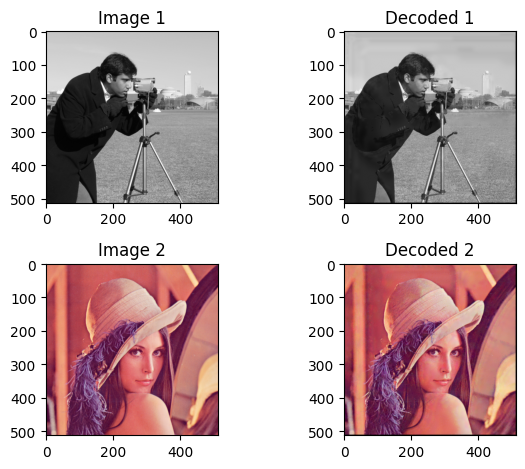

Depth = 5, a = 0.4, n = 16


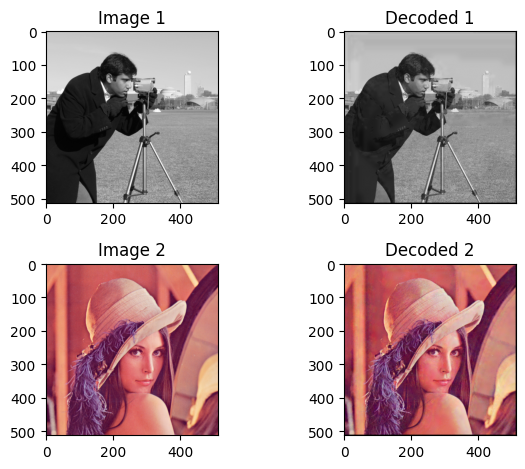

Depth = 5, a = 0.5, n = 16


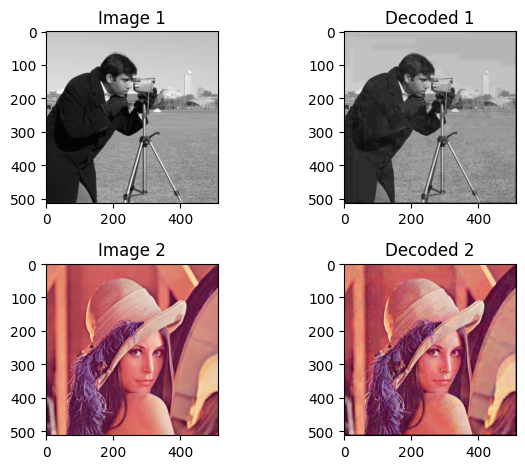

Depth = 5, a = 0.6, n = 16


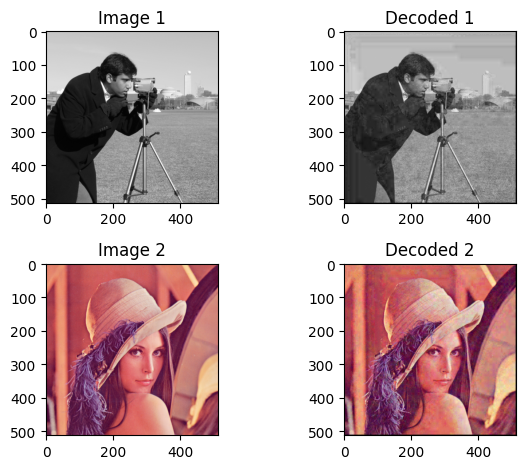

Depth = 5, a = 0.7, n = 16


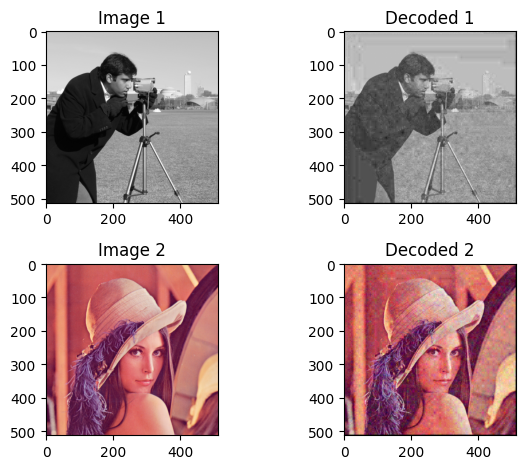

In [13]:
im1 = data.camera()
im2 = np.array(Image.open(r"/content/lena.png"))

depth = 5
n = 16
for a in [0.3, 0.4, 0.5, 0.6, 0.7]:
  l1 = LPyramid(im1, a, depth)
  q1 = L_Quantization(l1, n)
  dec1 = L_Pyramid_Decode(q1, a)
  l2 = LPyramid(im2, a, depth)
  q2 = L_Quantization(l2, n)
  dec2 = L_Pyramid_Decode(q2, a)
  fig, axes = plt.subplots(2, 2)
  print(f"Depth = {depth}, a = {a}, n = {n}")
  axes[0, 0].imshow(im1, cmap='gray')
  axes[0, 0].set_title('Image 1')
  axes[0, 1].imshow(dec1, cmap='gray')
  axes[0, 1].set_title('Decoded 1')
  axes[1, 0].imshow(im2)
  axes[1, 0].set_title('Image 2')
  axes[1, 1].imshow(dec2)
  axes[1, 1].set_title('Decoded 2')
  plt.tight_layout()
  plt.show()

Παρατηρούμε ότι καθώς αυξάνεται η παράμετρος α, η εικόνες παραμορφώνονται χρωματικά, με το φαινόμενο να είναι περισσότερο παρατηρήσιμο για τις τιμές α = 0.6 και  α = 0.7. Αυτό συμβαίνει διότι όσο αυξάνεται το α, τόσο λιγότερο ομαλό είναι το γκαουσιανό φίλτρο, δηλαδή λαμβάνει υπόψη του λιγότερο τα γειτονικά στοιχεία και περισσότερο το κεντρικό στοιχείο που εφαρμόζεται το φίλτρο. Ειδικότερα, από την τιμή 0.6 για το α και ύστερα, τα γειτονικά στοιχεία έχουν αρνητική συνεισφορά στην τιμή του κεντρικού, με αποτέλεσμα να θολώνεται το χρώμα του αποτελέσματος, δηλαδή ενώ τα γειτονικά και κεντρικά στοιχεία μπορεί να είναι μαύρα, επειδή τα γειτονικά λαμβάνονται ως το αντίθετο χρώμα, δηλαδή άσπρο, το αποτέλεσμα που προκύπτει είναι γκρί.

Depth = 3, a = 0.6, n = 16


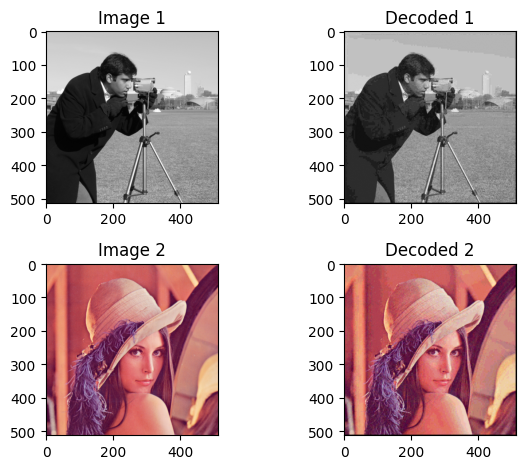

Depth = 4, a = 0.6, n = 16


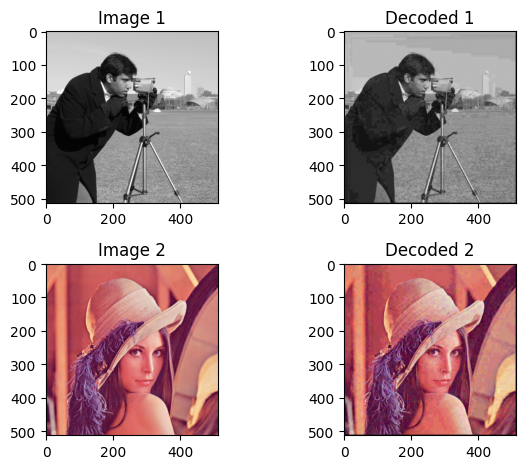

Depth = 5, a = 0.6, n = 16


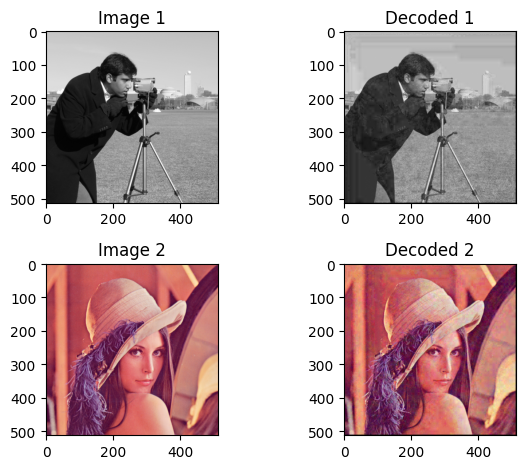

Depth = 6, a = 0.6, n = 16


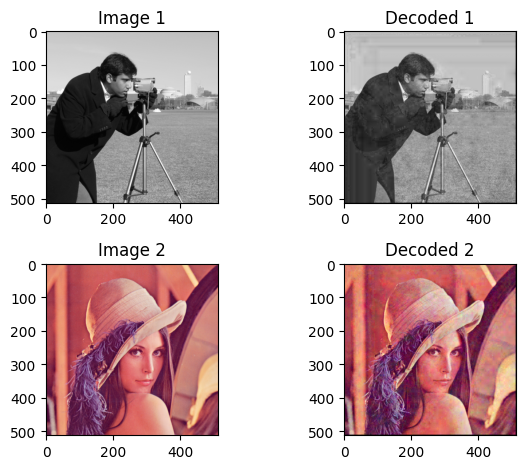

In [15]:
a = 0.6
n = 16
for depth in [3, 4, 5, 6]:
  l1 = LPyramid(im1, a, depth)
  q1 = L_Quantization(l1, n)
  dec1 = L_Pyramid_Decode(q1, a)
  l2 = LPyramid(im2, a, depth)
  q2 = L_Quantization(l2, n)
  dec2 = L_Pyramid_Decode(q2, a)
  fig, axes = plt.subplots(2, 2)
  print(f"Depth = {depth}, a = {a}, n = {n}")
  axes[0, 0].imshow(im1, cmap='gray')
  axes[0, 0].set_title('Image 1')
  axes[0, 1].imshow(dec1, cmap='gray')
  axes[0, 1].set_title('Decoded 1')
  axes[1, 0].imshow(im2)
  axes[1, 0].set_title('Image 2')
  axes[1, 1].imshow(dec2)
  axes[1, 1].set_title('Decoded 2')
  plt.tight_layout()
  plt.show()

Κρατώντας την τιμή της παραμέτρου α = 0.6, για την οποία παρατηρούνται εντονότερα οι αλλαγές, παρατηρούμε πως όσο αυξάνεται το βάθος της πυραμίδας, τόσο περισσότερο η εικόνα παραμορφώνεται. Αυτό οφείλεται στο ότι το φαινόμενο που παρατηρήθηκε στο προηγούμενο ερώτημα, όσο αυξάνονται τα επίπεδα της πυραμίδας, τόσο αυξάνεται η επίδραση του, εφόσον το φίλτρο εφαρμόζεται περισσότερες φορές.

In [16]:
entropy1 = []
n = 1

for i, a in enumerate([0.3, 0.4, 0.5, 0.6, 0.7]):
    entropy1.append([])
    for depth in [3, 4, 5, 6]:
        l1 = LPyramid(im1, a, depth)[0]
        q1 = L_Quantization(l1, n)
        entr1 = []
        for level in q1:
            entr1.append(entropy(level))
        entropy1[i].append(entr1)

entropy2 = []
for i, a in enumerate([0.3, 0.4, 0.5, 0.6, 0.7]):
    entropy2.append([])
    for depth in [3, 4, 5, 6]:
        l2 = LPyramid(im2, a, depth)
        q2 = L_Quantization(l2, n)
        entr2 = []
        for level1, level2, level3 in zip(q2[0], q2[1], q2[2]):
            entr2.append( (entropy(level1) + entropy(level2) + entropy(level3)) / 3 )
        entropy2[i].append(entr2)

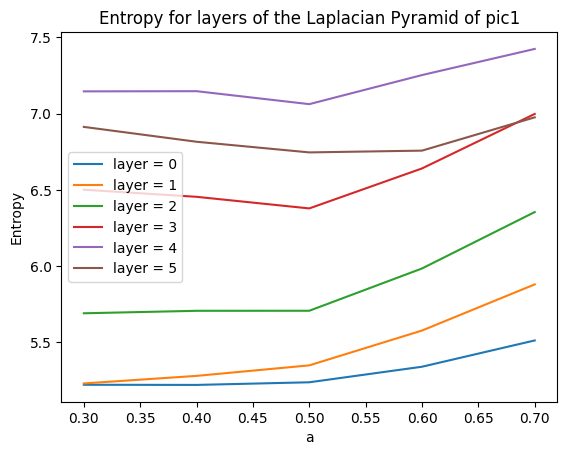

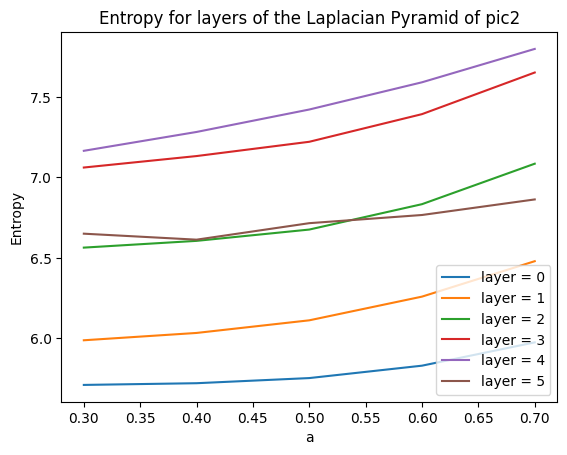

In [17]:
a = [0.3, 0.4, 0.5, 0.6, 0.7]
depth = [3, 4, 5, 6]
for i in range(6):
  for j in range(len(depth)):
    if depth[j] <= i: continue

    select = []
    for k in range(len(a)):
        select.append(entropy1[k][j][i])
  plt.plot(a, select, label = f'layer = {i}')

plt.title(f"Entropy for layers of the Laplacian Pyramid of pic1")
plt.xlabel("a")
plt.ylabel("Entropy")
plt.legend()
plt.show()

for i in range(6):
  for j in range(len(depth)):
    if depth[j] <= i: continue

    select = []
    for k in range(len(a)):
        select.append(entropy2[k][j][i])
  plt.plot(a, select, label = f'layer = {i}')

plt.title(f"Entropy for layers of the Laplacian Pyramid of pic2")
plt.xlabel("a")
plt.ylabel("Entropy")
plt.legend()
plt.show()

Από τα διαγράμματα συμπεραίνουμε ότι η εντροπία είναι χαμηλή γενικά για μικρότερες τιμές της παραμέτρου α και του βάθους της πυραμίδας. Αυτό συνάδει με τη θεωρία, καθώς στα χαμηλότερα επίπεδα αποτυπώνονται σχεδόν αποκλειστικά λεπτεπίλεπτες λεπτομέρειες, δηλαδή χαμηλές συχνότητες και μικρότερη εντροπία. Όσο αυξάνονται τα επίπεδα, οι λεπτομέρειες γίνονται πιο χοντροκομμένες, οπότε έχουμε υψηλότερες συχνότητες και μεγαλύτερες τιμές εντροπίας.

Η τιμή του α που ελαχιστοποιεί την τιμή της εντροπίας για την πρώτη εικόνα είναι 0.5, ενώ για τη δεύτερη είναι 0.3.

Experiment 1 (n = [16, 8, 4, 2, 1]) - Depth = 5, a1 = 0.5, n_values = [16, 8, 4, 2, 1]
Experiment 1 (n = [16, 8, 4, 2, 1]) - Depth = 5, a2 = 0.3, n_values = [16, 8, 4, 2, 1]


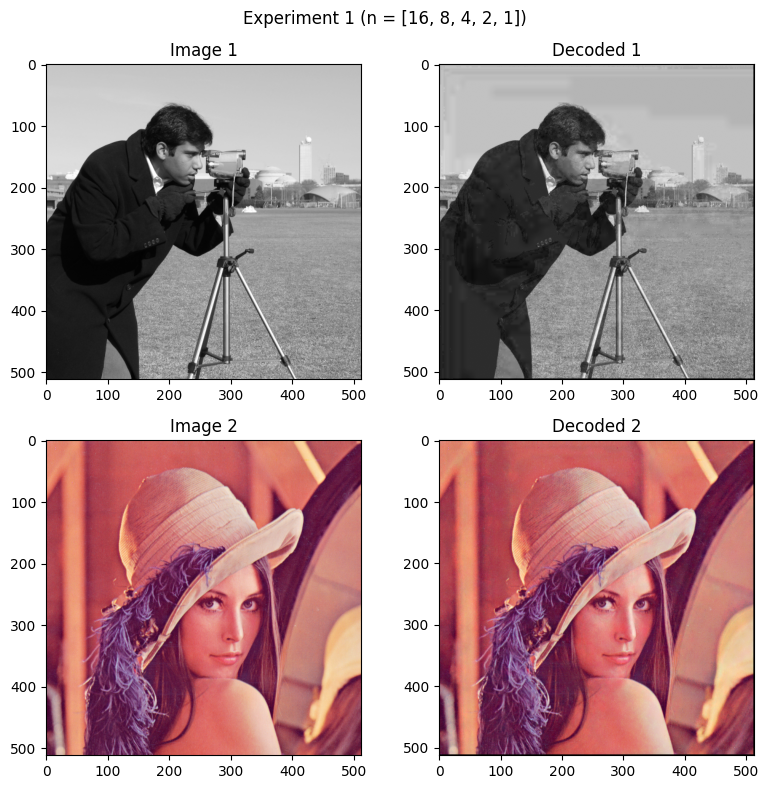

Experiment 2 (n = [4, 4, 4, 4, 4]) - Depth = 5, a1 = 0.5, n_values = [4, 4, 4, 4, 4]
Experiment 2 (n = [4, 4, 4, 4, 4]) - Depth = 5, a2 = 0.3, n_values = [4, 4, 4, 4, 4]


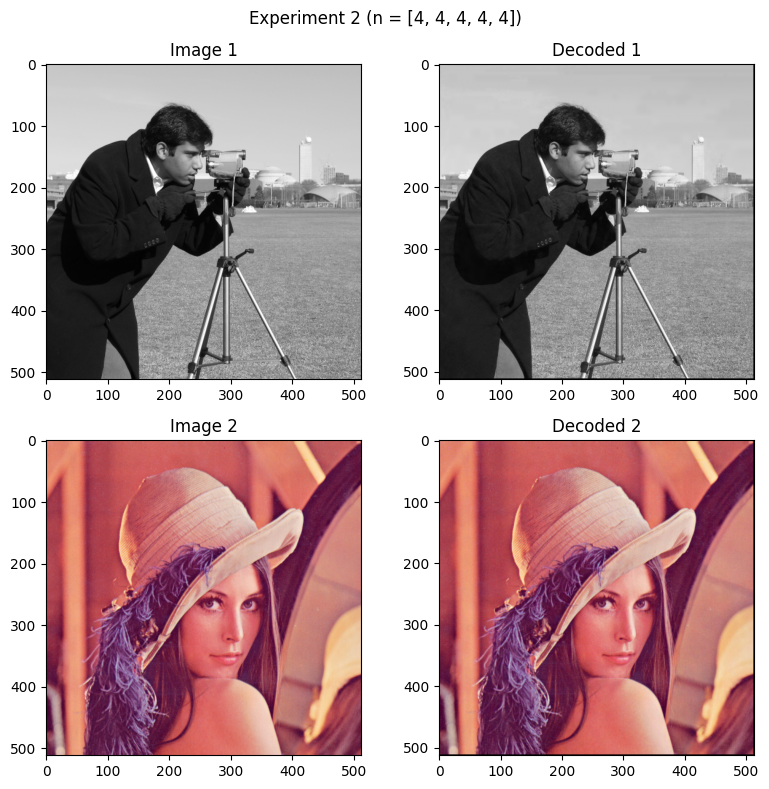

In [28]:
a1 = 0.5
a2 = 0.3
depth = 5

experiments = {
    "Experiment 1 (n = [16, 8, 4, 2, 1])": [16, 8, 4, 2, 1],
    "Experiment 2 (n = [4, 4, 4, 4, 4])": [4, 4, 4, 4, 4]
}

for exp_name, n_values in experiments.items():
    l1 = LPyramid(im1, a1, depth)
    q1 = [L_Quantization(l1[i], n_values[i]) for i in range(len(l1))]
    dec1 = L_Pyramid_Decode(q1, a1)

    l2 = LPyramid(im2, a2, depth)
    q2 = [L_Quantization(l2[i], n_values[i]) for i in range(len(l2))]
    dec2 = L_Pyramid_Decode(q2, a2)

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    print(f"{exp_name} - Depth = {depth}, a1 = {a1}, n_values = {n_values}")
    print(f"{exp_name} - Depth = {depth}, a2 = {a2}, n_values = {n_values}")

    axes[0, 0].imshow(im1, cmap='gray')
    axes[0, 0].set_title('Image 1')

    axes[0, 1].imshow(dec1, cmap='gray')
    axes[0, 1].set_title('Decoded 1')

    axes[1, 0].imshow(im2, cmap='gray')
    axes[1, 0].set_title('Image 2')

    axes[1, 1].imshow(dec2, cmap='gray')
    axes[1, 1].set_title('Decoded 2')

    plt.suptitle(exp_name)
    plt.tight_layout()
    plt.show()


Στα παραπάνω 2 πειράματα χρησιμοποιούμε δύο λίστες για το bin size των εικόνων ανάλογα με το επίπεδο της πυραμίδας, τις [16, 8, 4, 2, 1] και [4, 4, 4, 4, 4]. Το πρώτο πείραμα χρησιμοποιεί σημαντικά μικρότερο αριθμό bits για την αναπαράσταση των pixel σε σχέση με το δεύτερο. Αυτό που παρατηρούμε είναι πως οι αποκωδικοποιημένες εικόνες δεν διαφέρουν αισθητά, το οποίο σημαίνει ότι είναι προτιμότερο να διαβαθμίζουμε το μέγεθος των bin στα διαφορετικά επίπεδα της πυραμίδας ξεκινώντας με μεγάλο μέγεθος στα χαμηλά επίπεδα που έχουν μικρότερη εντροπία, και μικραίνοντας το καθώς προχωράμε στα ανώτερα επίπεδα, όπου η εντροπία αυξάνεται. Με τον τρόπο αυτό χρησιμοποιούμε μικρότερο αριθμο bits, χωρίς να χάνουμε σημαντική λεπτομέρεια.